<a href="https://colab.research.google.com/github/joao2000/Trabalhos/blob/main/Trabalho_3_PO240_Caixeiro_Viajante.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Trabalho 3**

#**Bibliotecas Úteis**

In [ ]:
!pip install ortools --quiet
!pip install haversine --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 10.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.31.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
from ortools.linear_solver import pywraplp
import random
from haversine import haversine

#Código para pegar a localizações (Lista de coordenadas)

In [ ]:
#Localidades:

#Com 10:
Locs = {
    "Jacutinga": (-22.281455786402542, -46.609587031772755),
    "Mogi Guaçu": (-22.368534234975613, -46.954837547114074),
    "Poços de Caldas": (-21.77796383357845, -46.602534618300794),
    "Sao Paulo 1": (-23.506410201286204, -46.718521218232446),
    "Cajamar": (-23.410712846830542, -46.82825781823618),
    "Sao Paulo 2": (-23.623357854088493, -46.69817247404677),
    "Piracicaba": (-22.703810129844417, -47.64984283360946),
    "Sorocaba": (-23.545119360709645, -47.46681376779295),
    "Osasco": (-23.541122873502214, -46.76666002008421),
    "Pouso Alegre": (-22.236223706226944, -45.88727641828312),
    "Rio Claro": (-22.406220702568852, -47.58536757224231)}

# Com 20:
# Locs = {
#     "Jacutinga": (-22.281455786402542, -46.609587031772755),# Saida: Jacutinga: R. Santo Antonio, 510 - Jacutinga, MG, 37590-000
#     "Mogi Guaçu": (-22.368534234975613, -46.954837547114074),# Mogi Guaçu: R. Francisco Franco de Godoy Bueno, 801 - Lot. Cidade Nova Mogi Guacu, Mogi Guaçu - SP, 13845-180
#     "Poços de Caldas": (-21.77796383357845, -46.602534618300794),# Poços de Caldas: Av. Silvio Monteiro dos Santos, 180 - Vale das Antas, Poços de Caldas - MG, 37704-369
#     "Sao Paulo 1": (-23.506410201286204, -46.718521218232446),# São Paulo: Av. Raimundo Pereira de Magalhães, 1465 - Jardim Iris, São Paulo - SP, 05145-000
#     "Cajamar": (-23.410712846830542, -46.82825781823618),# Cajamar: Mercadinho Empório Da Vila - R. Irmã de Morães, 13 - Jardim Santana, Cajamar - SP, 07750-000
#     "Sao Paulo 2": (-23.623357854088493, -46.69817247404677),# São Paulo: Av. Roque Petroni Júnior, 1089 - Jardim das Acacias, São Paulo - SP, 04707-900
#     "Piracicaba": (-22.703810129844417, -47.64984283360946),# Piracicaba: Shopping Piracicaba Av. Limeira, 722 - Areião, Piracicaba - SP, 13414-900
#     "Sorocaba": (-23.545119360709645, -47.46681376779295),# Sorocaba: Av. Gisele Constantino, 1850 - Parque Bela Vista, Votorantim - SP, 18110-650
#     "Osasco": (-23.541122873502214, -46.76666002008421),# Osaco: Shopping União de Osasco Av. dos Autonomistas, 1400 - Vila Yara, Osasco - SP, 06020-010
#     "Pouso Alegre": (-22.236223706226944, -45.88727641828312),# Pouso Alegre: BR-459, s/n Rodovia Presidente Juscelino Kubitschek, Km 107 - Ipiranga, Pouso Alegre - MG, 37556-140
#     "Rio Claro": (-22.406220702568852, -47.58536757224231),# Rio Claro: Shopping da Utilidade - Rio Claro R. 30, 2175 - Jardim Sao Paulo II, Rio Claro - SP, 13503-152

#     # Novos Shoppings
#     "Shopping Eldorado - SP": (-23.572216, -46.693964),
#     "Shopping Iguatemi Campinas - SP": (-22.852222, -47.059667),
#     "BH Shopping - BH": (-19.977755, -43.936018),
#     "Shopping Vitória - ES": (-20.301922, -40.288989),
#     "Shopping Praia da Costa - ES": (-20.329445, -40.291846),
#     "Shopping São José - RJ": (-22.718423, -43.175587),
#     "Shopping Tijuca - RJ": (-22.928994, -43.233218),
#     "Shopping Plaza Niterói - RJ": (-22.889981, -43.123598),
#     "Shopping Uberlândia - MG": (-18.917968, -48.276358),
#     "Shopping Parque Dom Pedro - SP": (-22.859888, -47.066181),
# }


#Tentativa por Haversine

In [ ]:
#Matriz de distancias
distancias = np.zeros((11, 11))
Locs_list = list(Locs.values())
Locs_keys = list(Locs.keys())
#print(Locs_list)

for i in range(0,11):
  for j in range(0,11):
    dist = haversine(Locs_list[i], Locs_list[j])
    #print(distancia)
    distancias[i][j]=round(dist,2)
print("Matriz de distâncias=",distancias)

Matriz de distâncias= [[  0.    36.81  55.99 136.67 127.55 149.49 116.74 165.69 140.99  74.5
  101.31]
 [ 36.81   0.    75.03 128.82 116.61 141.98  80.53 140.94 131.8  110.81
   64.96]
 [ 55.99  75.03   0.   192.56 183.03 205.43 149.05 215.58 196.78  89.63
  123.02]
 [136.67 128.82 192.56   0.    15.44  13.17 130.53  76.41   6.24 164.93
  151.14]
 [127.55 116.61 183.03  15.44   0.    27.11 115.08  66.82  15.8  162.34
  135.97]
 [149.49 141.98 205.43  13.17  27.11   0.   141.14  78.81  11.5  175.18
  162.98]
 [116.74  80.53 149.05 130.53 115.08 141.14   0.    95.4  129.71 188.42
   33.75]
 [165.69 140.94 215.58  76.41  66.82  78.81  95.4    0.    71.37 217.63
  127.22]
 [140.99 131.8  196.78   6.24  15.8   11.5  129.71  71.37   0.   170.79
  151.49]
 [ 74.5  110.81  89.63 164.93 162.34 175.18 188.42 217.63 170.79   0.
  175.69]
 [101.31  64.96 123.02 151.14 135.97 162.98  33.75 127.22 151.49 175.69
    0.  ]]


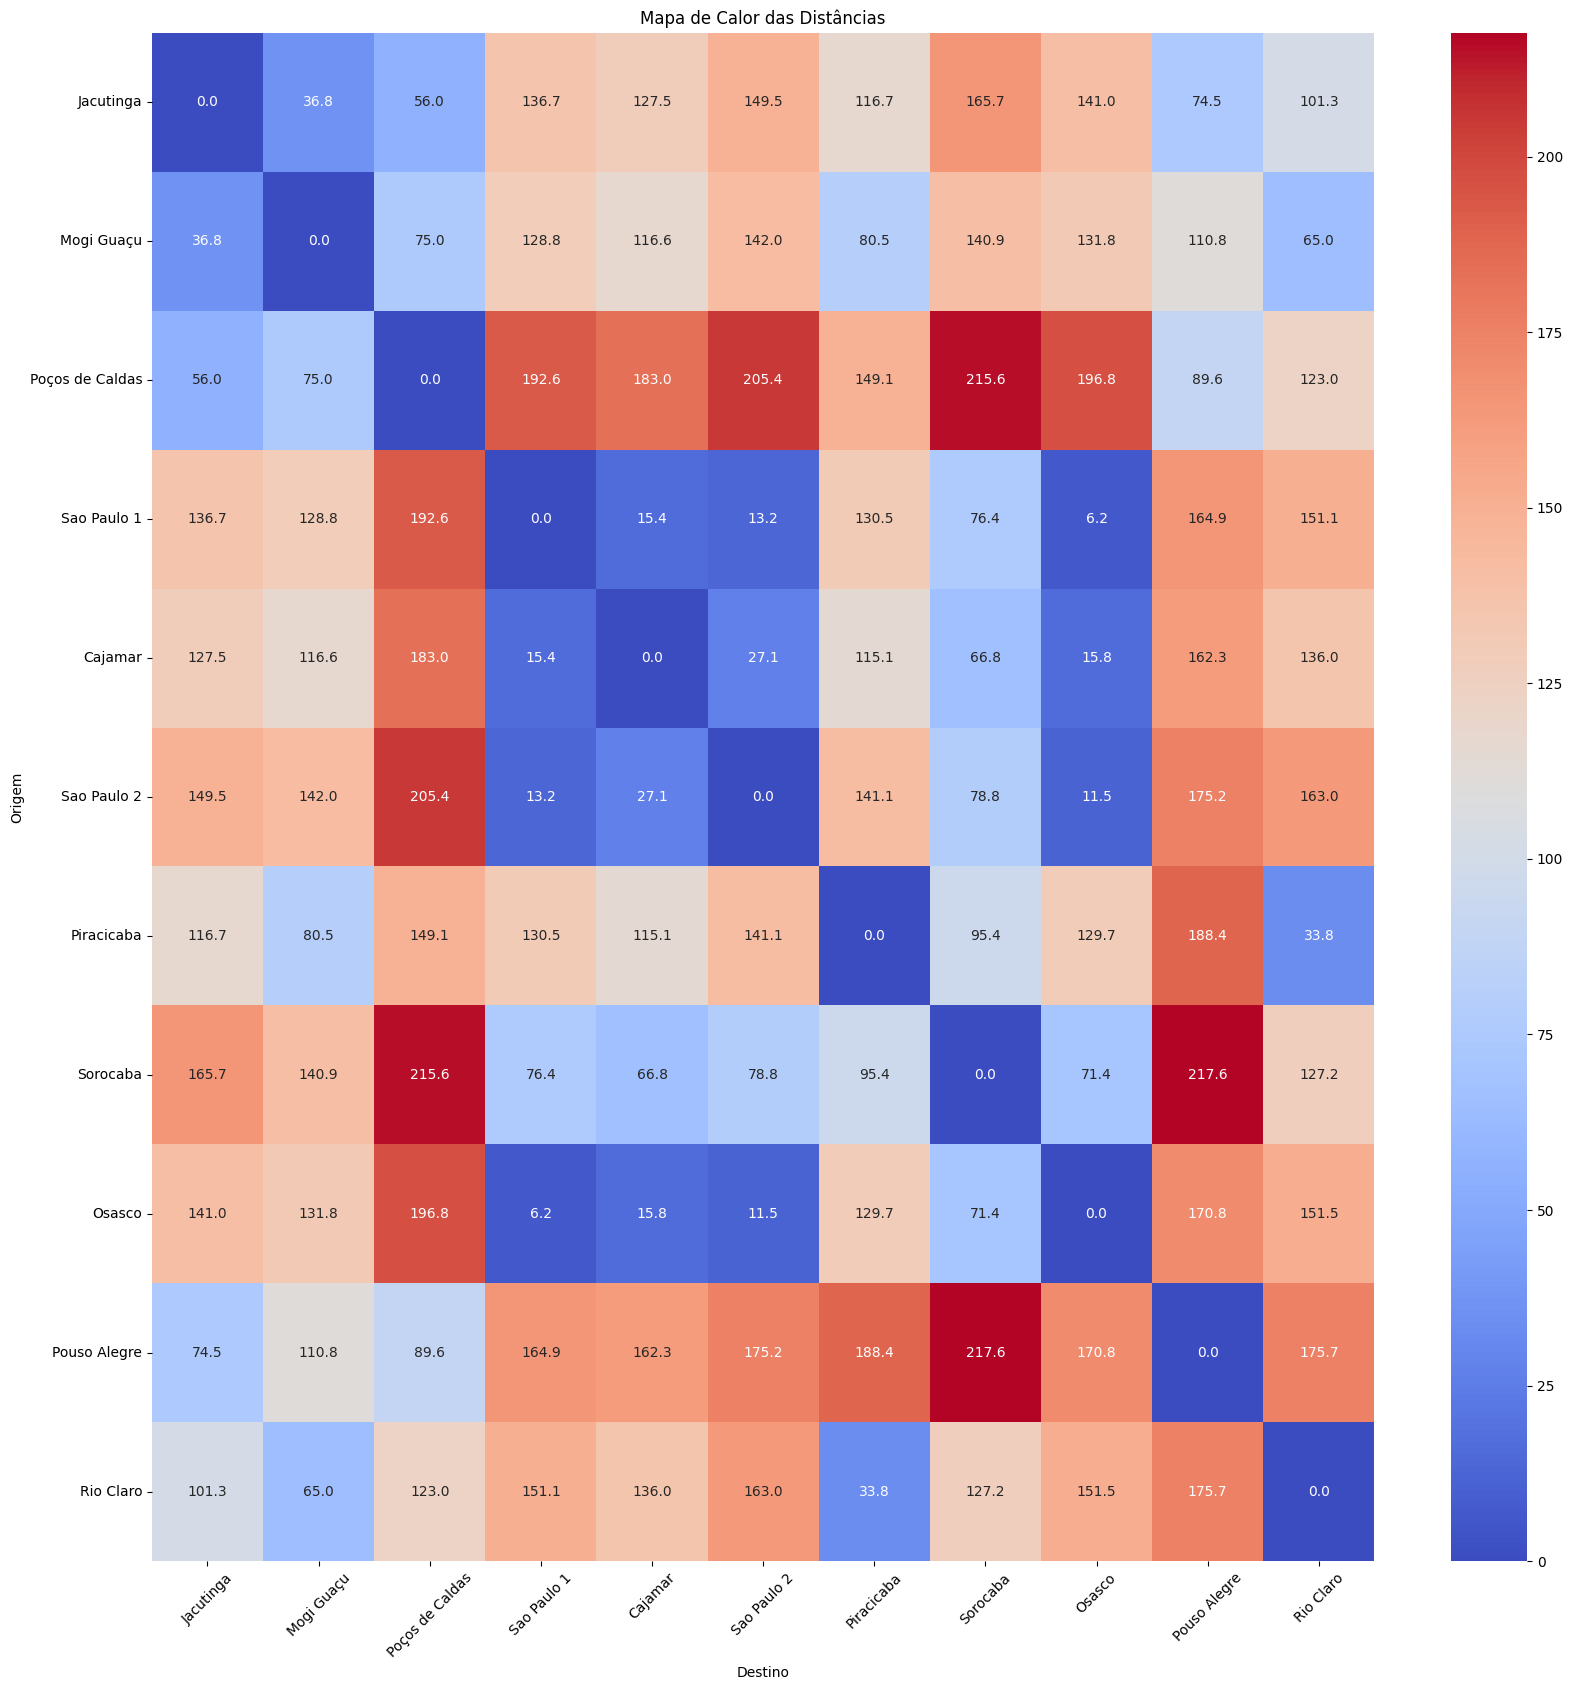

In [ ]:
df = pd.DataFrame(distancias, index=Locs_keys, columns=Locs_keys)
df
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Supondo que você já tem:
# df = pd.DataFrame(distancias, index=Locs_keys, columns=Locs_keys)

#Pra 10
#plt.figure(figsize=(12, 7))

#Pra 20:
plt.figure(figsize=(17,17))

sns.heatmap(df, annot=True, fmt=".1f", cmap="coolwarm")  # ou cmap="viridis", "coolwarm", etc.
plt.title("Mapa de Calor das Distâncias")
plt.xlabel("Destino")
plt.ylabel("Origem")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()#


#**Modelo Exato**

In [ ]:
nodos= 11
periodos= 1
max_vis= 11

In [ ]:
#Modelo

solver = pywraplp.Solver.CreateSolver("SCIP")

x = {}
for i in range(nodos):
    for j in range(nodos):
        if i != j:
            for t in range(periodos):
                x[i, j, t] = solver.BoolVar(f'x_{i}_{j}_{t}')

u = {}
for i in range(nodos):
    for t in range(periodos):
        u[i, t] = solver.NumVar(0.0, solver.infinity(), f'u_{i}_{t}')

soma = 0
for i in range(nodos):
  for j in range(nodos):
    for t in range(periodos):
      if i!=j:
        soma += x[i,j,t]*distancias[i,j]

solver.Minimize(soma)

# R1: Um nó i pode sair para no máximo um destino por período t
for i in range(nodos):
    for t in range(periodos):
        solver.Add(solver.Sum(x[i, j, t] for j in range(nodos) if i != j) <= 1)

# R2: Um nó j pode ser visitado por no máximo um nó por período t
for j in range(nodos):
    for t in range(periodos):
        solver.Add(solver.Sum(x[i, j, t] for i in range(nodos) if j != i) <= 1)

# R3: Cada nó i (exceto 0) deve ser visitado exatamente uma vez
for i in range(1, nodos):
    solver.Add(solver.Sum(x[i, j, t] for j in range(nodos) for t in range(periodos) if i != j) == 1)

# R4: O nó 0 (depósito) deve iniciar uma única rota por período
for t in range(periodos):
    solver.Add(solver.Sum(x[0, j, t] for j in range(nodos) if j != 0) == 1)

# R5: O nó 0 (depósito) deve receber uma única rota por período
for t in range(periodos):
    solver.Add(solver.Sum(x[i, 0, t] for i in range(1, nodos)) == 1)

# R6: Continuidade — número de entradas e saídas de cada nó k no período t deve ser igual
for k in range(nodos):
    for t in range(periodos):
        solver.Add(
            solver.Sum(x[i, k, t] for i in range(nodos) if i != k) ==
            solver.Sum(x[k, j, t] for j in range(nodos) if j != k)
        )

# R7: Subtour elimination usando variáveis contínuas u[i,t]
for i in range(1, nodos):
    for j in range(1, nodos):
        if i != j:
            for t in range(periodos):
                solver.Add(
                    u[i, t] - u[j, t] + nodos * x[i, j, t] <= nodos - 1)

print(solver.ExportModelAsLpFormat(obfuscate=False))

stauts = solver.Solve()

for var in solver.variables(): # Corrected method to access variables
  if var.solution_value() > 0:
    print(f'{var.name()} = {var.solution_value()}')

for t in range(periodos):
  print('Rota periodo %d' %(t+1))
  print('Inicio ' 'Fim ' 'Ativo ')
  for i in range(nodos):
    for j in range(nodos):
      if  (i!=j) and x[i,j,t].solution_value()>0:
        print(f'{i:3} {j:5} {int(x[i,j,t].solution_value()):4}')
  print('\n')

routeList = []

for t in range(periodos):
  print('Rota periodo %d' %(t+1))
  print('Inicio ' 'Fim ' 'Ativo ')
  for i in range(nodos):
    for j in range(nodos):
      if  (i!=j) and x[i,j,t].solution_value()>0:
        print(f'{Locs_keys[i]} {Locs_keys[j]} {int(x[i,j,t].solution_value()):4}')
        routeList.append([Locs_keys[i],Locs_keys[j]])
  print('\n')

print('Distancia minima: %d' % solver.Objective().Value())

print('\n')
origem = 0
print('Rota periodo %d' %(t+1))

tour = [0]

for i in range(nodos):
  for destino in range(nodos):
    if  (origem!=destino) and x[origem,destino,0].solution_value()>0:
      print(f'{Locs_keys[origem]} ====> {Locs_keys[destino]}')
      origem = destino
      tour.append(origem)

      print('\n')

print('\n')

print(tour)

print('Distancia minima: %d' % solver.Objective().Value())

#Desempenho do Modelo

print(f'Tempo de Solução {solver.wall_time()/1000}')

print(f'Nós BB {solver.nodes()}')

print(f'Iterações {solver.iterations()}')


\ Generated by MPModelProtoExporter
\   Name             : 
\   Format           : Free
\   Constraints      : 135
\   Variables        : 121
\     Binary         : 110
\     Integer        : 0
\     Continuous     : 11
Minimize
 Obj: +36.81 x_0_1_0 +55.99 x_0_2_0 +136.67 x_0_3_0 +127.55 x_0_4_0 +149.49 x_0_5_0 +116.74 x_0_6_0 +165.69 x_0_7_0 +140.99 x_0_8_0 +74.5 x_0_9_0 +101.31 x_0_10_0 +36.81 x_1_0_0 +75.03 x_1_2_0 +128.82 x_1_3_0 +116.61 x_1_4_0 +141.98 x_1_5_0 +80.53 x_1_6_0 +140.94 x_1_7_0 +131.8 x_1_8_0 +110.81 x_1_9_0 +64.96 x_1_10_0 +55.99 x_2_0_0 +75.03 x_2_1_0 +192.56 x_2_3_0 +183.03 x_2_4_0 +205.43 x_2_5_0 +149.05 x_2_6_0 +215.58 x_2_7_0 +196.78 x_2_8_0 +89.63 x_2_9_0 +123.02 x_2_10_0 +136.67 x_3_0_0 +128.82 x_3_1_0 +192.56 x_3_2_0 +15.44 x_3_4_0 +13.17 x_3_5_0 +130.53 x_3_6_0 +76.41 x_3_7_0 +6.24 x_3_8_0 +164.93 x_3_9_0 +151.14 x_3_10_0 +127.55 x_4_0_0 +116.61 x_4_1_0 +183.03 x_4_2_0 +15.44 x_4_3_0 +27.11 x_4_5_0 +115.08 x_4_6_0 +66.82 x_4_7_0 +15.8 x_4_8_0 +162.34 x_4_9_0

In [ ]:
#Desempenho do Modelo

print(f'Tempo de Solução {solver.wall_time()/1000}')

print(f'Nós BB {solver.nodes()}')

print(f'Iterações {solver.iterations()}')

Tempo de Solução 0.925
Nós BB 126
Iterações 2534


In [ ]:
#TESTE

rota = []
visitados = set()
origem = 0  # ou outro nó inicial, se for o caso
rota.append(Locs_keys[origem])

while True:
    encontrado = False
    for destino in range(nodos):
        if origem != destino and x[origem, destino, 0].solution_value() > 0.5:
            if destino in visitados:
                # Já visitado, evita ciclo (defensivo)
                continue
            rota.append(Locs_keys[destino])
            visitados.add(origem)
            origem = destino
            encontrado = True
            break
    if not encontrado:
        # Não há mais destino a partir daqui, fim da rota
        break

for cidade in rota:
    print(cidade)

Jacutinga
Poços de Caldas
Pouso Alegre
Sao Paulo 1
Sao Paulo 2
Osasco
Cajamar
Sorocaba
Piracicaba
Rio Claro
Mogi Guaçu


In [ ]:
import pandas as pd

# Inicializa a rota e variáveis auxiliares
rota = []
visitados = set()
origem = 0  # ou outro nó inicial, se for o caso
rota.append(Locs_keys[origem])

# Reconstrói a sequência da rota
while True:
    encontrado = False
    for destino in range(nodos):
        if origem != destino and x[origem, destino, 0].solution_value() > 0.5:
            if destino in visitados:
                continue
            rota.append(Locs_keys[destino])
            visitados.add(origem)
            origem = destino
            encontrado = True
            break
    if not encontrado:
        break

# Gera lista de pares (Origem, Destino)
rota_pares = []
for i in range(len(rota)-1):
    origem_nome = rota[i]
    destino_nome = rota[i + 1]
    rota_pares.append((i + 1, origem_nome, destino_nome,df.loc[origem_nome,destino_nome]))  # i+1 → número da rota
rota_pares.append((len(rota), rota[-1], rota[0],df.loc[rota[-1],rota[0]]))  # Fecha a rota
# Cria DataFrame
df_rota = pd.DataFrame(rota_pares, columns=["Rota", "Origem", "Destino","Distância (km)"])

# Soma total da rota
total_distancia = df_rota["Distância (km)"].sum()

# Cria uma linha extra com o total (sem origem/destino específicos)
df_rota.loc[len(df_rota)] = ["Total", "", "", total_distancia]

# Exibe resultado
print(df_rota)
df_rota.to_latex(float_format="%.2f",index=False)
#


     Rota           Origem          Destino  Distância (km)
0       1        Jacutinga  Poços de Caldas           55.99
1       2  Poços de Caldas     Pouso Alegre           89.63
2       3     Pouso Alegre      Sao Paulo 1          164.93
3       4      Sao Paulo 1      Sao Paulo 2           13.17
4       5      Sao Paulo 2           Osasco           11.50
5       6           Osasco          Cajamar           15.80
6       7          Cajamar         Sorocaba           66.82
7       8         Sorocaba       Piracicaba           95.40
8       9       Piracicaba        Rio Claro           33.75
9      10        Rio Claro       Mogi Guaçu           64.96
10     11       Mogi Guaçu        Jacutinga           36.81
11  Total                                            648.76


'\\begin{tabular}{lllr}\n\\toprule\nRota & Origem & Destino & Distância (km) \\\\\n\\midrule\n1 & Jacutinga & Poços de Caldas & 55.99 \\\\\n2 & Poços de Caldas & Pouso Alegre & 89.63 \\\\\n3 & Pouso Alegre & Sao Paulo 1 & 164.93 \\\\\n4 & Sao Paulo 1 & Sao Paulo 2 & 13.17 \\\\\n5 & Sao Paulo 2 & Osasco & 11.50 \\\\\n6 & Osasco & Cajamar & 15.80 \\\\\n7 & Cajamar & Sorocaba & 66.82 \\\\\n8 & Sorocaba & Piracicaba & 95.40 \\\\\n9 & Piracicaba & Rio Claro & 33.75 \\\\\n10 & Rio Claro & Mogi Guaçu & 64.96 \\\\\n11 & Mogi Guaçu & Jacutinga & 36.81 \\\\\nTotal &  &  & 648.76 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [ ]:
import folium

coords_brasil = [-16.089461610967666, -55.910299337040286]
coords_sp = [-23.5509378979565, -46.6398829009542]
map = folium.Map(location= coords_sp, zoom_start=7, tiles="cartodbpositron")
map

In [ ]:
def drawCities(dic, map):
  #For each city draw CircleMarker point in the Map
  indice = 0
  for item in dic.items():
      folium.CircleMarker(
          location=[item[1][0], item[1][1]],
          radius = 6,
          popup=str(indice+1)+': '+item[0],
          color='blue',
          fill=True, # Set fill to True
          fill_color='lightblue',
          fill_opacity=0.7
      ).add_to(map)

  return map

map = drawCities(Locs, map)
map


In [ ]:
def createRoute(Routes, dic, map):
  for route in Routes:

      start_point = dic[route[0]]

      end_point = dic[route[1]]

      route = [start_point, end_point]

      folium.PolyLine(route,
                    weight=8,
                    color='green',
                    opacity=0.6).add_to(map)

  return map

map = createRoute(routeList,Locs, map)
map

#**Simulated Anealing**

In [ ]:
import math

def solve_tsp_nearest(distances):
    num_cities = len(distances)
    visited = [False] * num_cities
    tour = []
    total_distance = 0

    # Start at the first city
    current_city = 0
    tour.append(current_city)
    visited[current_city] = True


    # Repeat until all cities have been visited
    while len(tour) < num_cities:
        nearest_city = None
        nearest_distance = math.inf

        # Find the nearest unvisited city
        for city in range(num_cities):
            if not visited[city]:
                distance = distances[current_city][city]
                if distance < nearest_distance:
                    nearest_city = city
                    nearest_distance = distance

        # Move to the nearest city
        current_city = nearest_city
        tour.append(current_city)
        visited[current_city] = True
        total_distance += nearest_distance

    # Complete the tour by returning to the starting city
    tour.append(0)
    total_distance += distances[current_city][0]

    return tour, total_distance

tour, total_distance = solve_tsp_nearest(distancias)

print("Tour:", tour)
print("Total distance:", total_distance)


Tour: [0, 1, 12, 20, 6, 10, 2, 9, 4, 3, 8, 11, 5, 7, 17, 18, 16, 13, 15, 14, 19, 0]
Total distance: 3111.0099999999998


In [ ]:
# knapsack solved by
# using classical simulated annealing

# Toy problem to test
# items  0  1  2  3  4  5  6  7  8  9
# values 79 32 47 18 26 85 33 40 45 59
# sizes 85 26 48 21 22 95 43 45 55 52
# max size = 101

# maximize value

import numpy as np
import time
def get_data_problem():
  matriz = distancias
  #Para 10:
  #sol_ini = [0, 1, 10, 6, 7, 4, 3, 8, 5, 9, 2]
  #Para 20:
  sol_ini = [0, 1, 10, 6, 7, 4, 3, 8, 5, 9, 2, 11, 13, 14, 15, 12, 16, 17, 18, 19]
  return matriz,sol_ini


def total_valu_size(route, matriz):
  # total value and size of a specified packing
  total_dist = 0.0  # total valu of packing
  n = len(route)

  for i in range(n):
    if i < n-1:
      total_dist += matriz[route[i],route[i+1]]
    else:
      total_dist += matriz[route[i],route[0]]

  return total_dist

def adjacent(sol,rnd):
  n = len(sol)
  p = rnd.randint(1, n-2)
  sol2a = sol[0:p]
  sol2b = sol[p:][::-1]
  sol2a = sol2a + sol2b
  return sol2a

def solve_sa(sol, matriz,rnd, max_iter, start_temperature, alpha):

  n_items = len(sol)
  # solve using simulated annealing
  curr_temperature = start_temperature
  curr_route = sol
  print("Initial guess: ")
  print(sol)

  cur_route_distance = total_valu_size(curr_route, matriz)
  print("Initial distance: ")
  print(cur_route_distance)
  iteration = 0
  interval = (int)(max_iter / 10)
  while iteration <= max_iter:
    # pct_iters_left = \
    #  (max_iter - iteration) / (max_iter * 1.0)
    adj_route = adjacent(curr_route,rnd)
    adj_route_dist = total_valu_size(adj_route,matriz)

    if adj_route_dist < cur_route_distance:  # better so accept adjacent
      curr_route = adj_route
      cur_route_distance = adj_route_dist
    else:          # adjacent packing is worse
      accept_p = \
        np.exp( ( cur_route_distance - adj_route_dist) / curr_temperature )
      p = rnd.random()
      if p <= accept_p:  # accept worse packing anyway
        curr_route = adj_route
        cur_route_distance = adj_route_dist
      # else don't accept

    if iteration % interval == 0:
      print("iter = %6d : curr value = %7.2f : \
        curr temp = %10.2f"      \
        % (iteration, cur_route_distance, curr_temperature))

    if curr_temperature <= 0.00001:
      curr_temperature = 0.00001
    else:
      curr_temperature *= alpha
      # curr_temperature = start_temperature * \
      # pct_iters_left * 0.0050
    iteration += 1
  return curr_route

def solve_toy_problem():
  time_ini = time.time()
  print("\nBegin knapsack simulated annealing demo ")
  print("Goal is to maximize value subject \
    to max size constraint ")

  # Obtaining the data of the problem
  matriz_dist, sol_inicial = get_data_problem()

  # print("\nItem values: ")
  # print(values)
  # print("\nItem sizes: ")
  # print(sizes)
  # print("\nMax total size = %d " % max_size)

  # Setting simulated annealing parameters
  rnd = np.random.RandomState(5)  # 3 .98 = 117,100
  max_iter = 1000
  start_temperature = 100000.0
  alpha = 0.99

  print("\nSettings: ")
  print("max_iter = %d " % max_iter)
  print("start_temperature = %0.1f " \
    % start_temperature)
  print("alpha = %0.2f " % alpha)

  # Calling the function that employs SA to solve the problem
  print("\nStarting solve() ")
  final_route = solve_sa( sol_inicial, matriz_dist,
                     rnd, max_iter, start_temperature, alpha)
  print("Finished solve() ")

  print("\nBest route found: ")
  final_route_distance = total_valu_size(final_route,matriz_dist)

  print(f'Best route = {final_route}')
  print(f'Best distance = {final_route_distance}')

  print("\nEnd demo ")
  time_end = time.time()

  timeto = time_end - time_ini

  print(f'Tempo {timeto}')
  return final_route, final_route_distance
sa_route, sa_distance = solve_toy_problem()


Begin knapsack simulated annealing demo 
Goal is to maximize value subject     to max size constraint 

Settings: 
max_iter = 1000 
start_temperature = 100000.0 
alpha = 0.99 

Starting solve() 
Initial guess: 
[0, 1, 10, 6, 7, 4, 3, 8, 5, 9, 2, 11, 13, 14, 15, 12, 16, 17, 18, 19]
Initial distance: 
3966.16
iter =      0 : curr value = 4050.15 :         curr temp =  100000.00
iter =    100 : curr value = 6830.81 :         curr temp =   36603.23
iter =    200 : curr value = 6591.28 :         curr temp =   13397.97
iter =    300 : curr value = 6678.61 :         curr temp =    4904.09
iter =    400 : curr value = 6172.25 :         curr temp =    1795.06
iter =    500 : curr value = 5212.16 :         curr temp =     657.05
iter =    600 : curr value = 5978.02 :         curr temp =     240.50
iter =    700 : curr value = 4674.40 :         curr temp =      88.03
iter =    800 : curr value = 4078.98 :         curr temp =      32.22
iter =    900 : curr value = 3677.69 :         curr temp =  

In [ ]:
import folium

coords_brasil = [-16.089461610967666, -55.910299337040286]
coords_sp = [-23.5509378979565, -46.6398829009542]
map = folium.Map(location= coords_sp, zoom_start=7, tiles="cartodbpositron")

def drawCities(dic, map):
  #For each city draw CircleMarker point in the Map
  indice = 0
  for item in dic.items():
      folium.CircleMarker(
          location=[item[1][0], item[1][1]],
          radius = 6,
          popup=str(indice+1)+': '+item[0],
          color='blue',
          fill=True, # Set fill to True
          fill_color='lightblue',
          fill_opacity=0.7
      ).add_to(map)

  return map

map = drawCities(Locs, map)

# def createRoute(Routes, dic, map):
#   for route in Routes:

#       start_point = dic[route[0]]

#       end_point = dic[route[1]]

#       route = [start_point, end_point]

#       folium.PolyLine(route,
#                     weight=8,
#                     color='green',
#                     opacity=0.6).add_to(map)

#   return map

def createRoute(Routes, dic, map):
  for i in range(len(Routes)):
    if i < len(Routes)-1:
      start_point = dic[list(dic.keys())[Routes[i]]]

      end_point = dic[list(dic.keys())[Routes[i+1]]]

    else:
      start_point = dic[list(dic.keys())[Routes[i]]]

      end_point = dic[list(dic.keys())[Routes[0]]]

    route = [start_point, end_point]

    folium.PolyLine(route,
                    weight=8,
                    color='green',
                    opacity=0.6).add_to(map)

  return map

map = createRoute(sa_route, Locs, map)
map

In [ ]:
import pandas as pd

# Gera lista de pares (Origem, Destino)
rota_pares = []
for i in range(len(sa_route)-1):
    origem_nome = Locs_keys[sa_route[i]]
    destino_nome = Locs_keys[sa_route[i+1]]
    rota_pares.append((i + 1, origem_nome, destino_nome, df.loc[origem_nome,destino_nome]))  # i+1 → número da rota
rota_pares.append((len(sa_route), Locs_keys[sa_route[-1]], Locs_keys[sa_route[0]], df.loc[Locs_keys[sa_route[-1]],Locs_keys[sa_route[0]]]))  # Fecha a rota
# Cria DataFrame
df_rota = pd.DataFrame(rota_pares, columns=["Rota", "Origem", "Destino","Distância (km)"])

# Soma total da rota
total_distancia = df_rota["Distância (km)"].sum()

# Cria uma linha extra com o total (sem origem/destino específicos)
df_rota.loc[len(df_rota)] = ["Total", "", "", total_distancia]

# Exibe resultado
print(df_rota)
df_rota.to_latex(float_format="%.2f",index=False)
#

     Rota                           Origem                          Destino  \
0       1                        Jacutinga                  Poços de Caldas   
1       2                  Poços de Caldas         Shopping Uberlândia - MG   
2       3         Shopping Uberlândia - MG     Shopping Praia da Costa - ES   
3       4     Shopping Praia da Costa - ES           Shopping São José - RJ   
4       5           Shopping São José - RJ      Shopping Plaza Niterói - RJ   
5       6      Shopping Plaza Niterói - RJ             Shopping Tijuca - RJ   
6       7             Shopping Tijuca - RJ                 BH Shopping - BH   
7       8                 BH Shopping - BH            Shopping Vitória - ES   
8       9            Shopping Vitória - ES                     Pouso Alegre   
9      10                     Pouso Alegre  Shopping Iguatemi Campinas - SP   
10     11  Shopping Iguatemi Campinas - SP           Shopping Eldorado - SP   
11     12           Shopping Eldorado - SP          

'\\begin{tabular}{lllr}\n\\toprule\nRota & Origem & Destino & Distância (km) \\\\\n\\midrule\n1 & Jacutinga & Poços de Caldas & 55.99 \\\\\n2 & Poços de Caldas & Shopping Uberlândia - MG & 362.74 \\\\\n3 & Shopping Uberlândia - MG & Shopping Praia da Costa - ES & 850.77 \\\\\n4 & Shopping Praia da Costa - ES & Shopping São José - RJ & 399.41 \\\\\n5 & Shopping São José - RJ & Shopping Plaza Niterói - RJ & 19.81 \\\\\n6 & Shopping Plaza Niterói - RJ & Shopping Tijuca - RJ & 12.04 \\\\\n7 & Shopping Tijuca - RJ & BH Shopping - BH & 336.12 \\\\\n8 & BH Shopping - BH & Shopping Vitória - ES & 382.43 \\\\\n9 & Shopping Vitória - ES & Pouso Alegre & 618.63 \\\\\n10 & Pouso Alegre & Shopping Iguatemi Campinas - SP & 138.52 \\\\\n11 & Shopping Iguatemi Campinas - SP & Shopping Eldorado - SP & 88.35 \\\\\n12 & Shopping Eldorado - SP & Cajamar & 22.58 \\\\\n13 & Cajamar & Sao Paulo 1 & 15.44 \\\\\n14 & Sao Paulo 1 & Osasco & 6.24 \\\\\n15 & Osasco & Sao Paulo 2 & 11.50 \\\\\n16 & Sao Paulo 2 & S

#**Código do genético**

1. Parâmetros do algoritmo genético

In [ ]:
# Imports
import numpy as np
import random

from datetime import datetime

# Parameters
#Para 10:
n_cities = 11
#Para 20:
#n_cities = 21

n_population = 300

mutation_rate = 0.3

2. Definindo os dados das cidades

In [ ]:
#Trocando a lista de cidades:

#Para 10:
names_list = np.array(['Jacutinga','Mogi Guaçu','Poços de Caldas','Sao Paulo 1','Cajamar','Sao Paulo 2','Piracicaba','Sorocaba','Osasco','Pouso Alegre','Rio Claro'])
#Para 20:
# names_list = np.array(['Jacutinga','Mogi Guaçu','Poços de Caldas','Sao Paulo 1','Cajamar','Sao Paulo 2','Piracicaba','Sorocaba','Osasco','Pouso Alegre','Rio Claro',
#                        "Shopping Eldorado - SP","Shopping Iguatemi Campinas - SP","BH Shopping - BH","Shopping Vitória - ES","Shopping Praia da Costa - ES",
#                        "Shopping São José - RJ","Shopping Tijuca - RJ","Shopping Plaza Niterói - RJ","Shopping Uberlândia - MG","Shopping Parque Dom Pedro - SP"])

cities_dict = {
    "Jacutinga": (-22.281455786402542, -46.609587031772755),
    "Mogi Guaçu": (-22.368534234975613, -46.954837547114074),
    "Poços de Caldas": (-21.77796383357845, -46.602534618300794),
    "Sao Paulo 1": (-23.506410201286204, -46.718521218232446),
    "Cajamar": (-23.410712846830542, -46.82825781823618),
    "Sao Paulo 2": (-23.623357854088493, -46.69817247404677),
    "Piracicaba": (-22.703810129844417, -47.64984283360946),
    "Sorocaba": (-23.545119360709645, -47.46681376779295),
    "Osasco": (-23.541122873502214, -46.76666002008421),
    "Pouso Alegre": (-22.236223706226944, -45.88727641828312),
    "Rio Claro": (-22.406220702568852, -47.58536757224231)
}

# Com 20:
# cities_dict = {
#     "Jacutinga": (-22.281455786402542, -46.609587031772755),
#     "Mogi Guaçu": (-22.368534234975613, -46.954837547114074),
#     "Poços de Caldas": (-21.77796383357845, -46.602534618300794),
#     "Sao Paulo 1": (-23.506410201286204, -46.718521218232446),
#     "Cajamar": (-23.410712846830542, -46.82825781823618),
#     "Sao Paulo 2": (-23.623357854088493, -46.69817247404677),
#     "Piracicaba": (-22.703810129844417, -47.64984283360946),
#     "Sorocaba": (-23.545119360709645, -47.46681376779295),
#     "Osasco": (-23.541122873502214, -46.76666002008421),
#     "Pouso Alegre": (-22.236223706226944, -45.88727641828312),
#     "Rio Claro": (-22.406220702568852, -47.58536757224231),

#     # Novos Shoppings
#     "Shopping Eldorado - SP": (-23.572216, -46.693964),
#     "Shopping Iguatemi Campinas - SP": (-22.852222, -47.059667),
#     "BH Shopping - BH": (-19.977755, -43.936018),
#     "Shopping Vitória - ES": (-20.301922, -40.288989),
#     "Shopping Praia da Costa - ES": (-20.329445, -40.291846),
#     "Shopping São José - RJ": (-22.718423, -43.175587),
#     "Shopping Tijuca - RJ": (-22.928994, -43.233218),
#     "Shopping Plaza Niterói - RJ": (-22.889981, -43.123598),
#     "Shopping Uberlândia - MG": (-18.917968, -48.276358),
#     "Shopping Parque Dom Pedro - SP": (-22.859888, -47.066181),
# }


#Como substituir pela matriz de distancias?
# distancias
# dist = haversine(Locs_list[i], Locs_list[j])

# Function to compute the distance between two points
def compute_city_distance_coordinates(a,b):
    return haversine(a, b)

def compute_city_distance_names(city_a, city_b, cities_dict):
    return compute_city_distance_coordinates(cities_dict[city_a], cities_dict[city_b])

print(compute_city_distance_names('Osasco', 'Rio Claro', cities_dict))
cities_dict

151.49259034387862


{'Jacutinga': (-22.281455786402542, -46.609587031772755),
 'Mogi Guaçu': (-22.368534234975613, -46.954837547114074),
 'Poços de Caldas': (-21.77796383357845, -46.602534618300794),
 'Sao Paulo 1': (-23.506410201286204, -46.718521218232446),
 'Cajamar': (-23.410712846830542, -46.82825781823618),
 'Sao Paulo 2': (-23.623357854088493, -46.69817247404677),
 'Piracicaba': (-22.703810129844417, -47.64984283360946),
 'Sorocaba': (-23.545119360709645, -47.46681376779295),
 'Osasco': (-23.541122873502214, -46.76666002008421),
 'Pouso Alegre': (-22.236223706226944, -45.88727641828312),
 'Rio Claro': (-22.406220702568852, -47.58536757224231)}

3. Criando a primeira população do AG

Sorteio aleatório de N cidades onde N é o tamanho da população

In [ ]:
# First step: Create the first population set
def genesis(city_list, n_population):

    population_set = []
    for i in range(n_population):
        #Randomly generating a new solution
        sol_i = city_list[np.random.choice(list(range(n_cities)), n_cities, replace=False)]
        population_set.append(sol_i)
    return np.array(population_set)

population_set = genesis(names_list, n_population)
population_set

array([['Pouso Alegre', 'Rio Claro', 'Piracicaba', ..., 'Mogi Guaçu',
        'Poços de Caldas', 'Sao Paulo 1'],
       ['Poços de Caldas', 'Sao Paulo 1', 'Rio Claro', ..., 'Osasco',
        'Cajamar', 'Mogi Guaçu'],
       ['Piracicaba', 'Sorocaba', 'Jacutinga', ..., 'Rio Claro',
        'Cajamar', 'Sao Paulo 1'],
       ...,
       ['Sorocaba', 'Cajamar', 'Pouso Alegre', ..., 'Sao Paulo 1',
        'Piracicaba', 'Jacutinga'],
       ['Jacutinga', 'Piracicaba', 'Poços de Caldas', ..., 'Rio Claro',
        'Sao Paulo 2', 'Osasco'],
       ['Osasco', 'Jacutinga', 'Cajamar', ..., 'Sorocaba', 'Mogi Guaçu',
        'Piracicaba']], dtype='<U31')

4. Avaliando o fitness das soluções

As soluções são definidas de forma que o primeiro elemento da lista seja a primeira cidade a visitar, depois a segunda, etc. e a última cidade esteja ligada à primeira. A função de aptidão precisa calcular a distância entre as cidades subsequentes.

In [ ]:
# Avaliação de 1 indivíduo.
def fitness_eval(city_list, cities_dict):
    total = 0
    for i in range(n_cities-1):
        a = city_list[i]
        b = city_list[i+1]
        total += compute_city_distance_names(a,b, cities_dict)
    a = city_list[n_cities-1]
    b = city_list[0]
    total += compute_city_distance_names(a,b, cities_dict)

    return total

print('Cities = ', population_set[0])
print('Fitness = ', fitness_eval(population_set[0], cities_dict))

Cities =  ['Pouso Alegre' 'Rio Claro' 'Piracicaba' 'Sao Paulo 2' 'Cajamar'
 'Jacutinga' 'Osasco' 'Sorocaba' 'Mogi Guaçu' 'Poços de Caldas'
 'Sao Paulo 1']
Fitness =  1291.0657681362754


In [ ]:
# Avaliação de todos os indivíduos da população.
def get_all_fitnes(population_set, cities_dict):
    fitnes_list = np.zeros(n_population)

    #Looping over all solutions computing the fitness for each solution
    for i in range(n_population):
        fitnes_list[i] = fitness_eval(population_set[i], cities_dict)

    return fitnes_list

fitnes_list = get_all_fitnes(population_set,cities_dict)
fitnes_list

array([1291.06576814, 1361.64071526, 1183.67802592, 1242.51437227,
       1138.48953147, 1579.0262798 , 1570.39793499, 1370.92371616,
        998.10018665, 1113.45029455, 1346.99530779, 1374.14785481,
       1524.38495954, 1513.00182498, 1205.7191238 , 1257.64835392,
       1394.12272542, 1175.00759355, 1315.57220844, 1196.98029939,
       1347.3231595 , 1358.96720193, 1234.51859522, 1412.16349118,
       1312.11758203, 1441.99443961, 1436.16684367, 1490.83648549,
       1278.49692345,  942.2412291 , 1256.00232497, 1430.950536  ,
       1491.99026869, 1103.01849326, 1343.49145652, 1241.58303302,
       1268.99633847, 1166.66160002, 1364.5431838 , 1487.77096209,
       1431.01263795, 1252.80629516, 1042.30180616, 1605.72646491,
       1161.78305969,  965.61755267, 1427.45707765, 1515.73992214,
       1470.11034804, 1129.29437496, 1211.69951444, 1114.76725755,
       1401.98128571, 1544.70065707, 1425.47944294, 1229.99099697,
       1581.93805503, 1318.50767749, 1273.34763076, 1244.54446

5. Seleção de Progenitores

Deve ser selecionado um novo conjunto de progenitores, usando a Seleção da Roleta. Gera uma lista de pares de progenitores onde N= len(population_set), mas em cada posição existem duas soluções para mesclar.

In [ ]:
def progenitor_selection(population_set,fitnes_list):
    total_fit = fitnes_list.sum()
    prob_list = fitnes_list/total_fit

    #Notice there is the chance that a progenitor. mates with oneself
    progenitor_list_a = np.random.choice(list(range(len(population_set))), len(population_set),p=prob_list, replace=True)
    progenitor_list_b = np.random.choice(list(range(len(population_set))), len(population_set),p=prob_list, replace=True)
    #print(progenitor_list_a)

    progenitor_list_a = population_set[progenitor_list_a]
    progenitor_list_b = population_set[progenitor_list_b]

    return np.array([progenitor_list_a,progenitor_list_b])


progenitor_list = progenitor_selection(population_set,fitnes_list)
print(progenitor_list[0][0])
print(progenitor_list[1][0])

['Mogi Guaçu' 'Osasco' 'Jacutinga' 'Sao Paulo 1' 'Sao Paulo 2' 'Rio Claro'
 'Sorocaba' 'Cajamar' 'Pouso Alegre' 'Piracicaba' 'Poços de Caldas']
['Mogi Guaçu' 'Osasco' 'Sao Paulo 2' 'Sorocaba' 'Rio Claro'
 'Poços de Caldas' 'Piracicaba' 'Jacutinga' 'Sao Paulo 1' 'Pouso Alegre'
 'Cajamar']


# 4. Geração de novos filhos a partir dos pais

Para cada par de pais, geraremos um par de descendentes. Como não podemos repetir cidades, o que faremos é copiar um pedaço aleatório de um progenitor e preencher os espaços em branco com o outro progenitor.

## 4.1. Geração de 1 filho

In [ ]:
def mate_progenitors(prog_a, prog_b):
    offspring = prog_a[0:5]

    for city in prog_b:

        if not city in offspring:
            offspring = np.concatenate((offspring,[city]))

    return offspring

prog_a, prog_b = progenitor_list[0][1], progenitor_list[1][1]
offspring = mate_progenitors(prog_a, prog_b)
print('Pais')
print(prog_a)
print(prog_b)
print('Filho')
print(offspring)

Pais
['Cajamar' 'Rio Claro' 'Osasco' 'Jacutinga' 'Sorocaba' 'Poços de Caldas'
 'Pouso Alegre' 'Piracicaba' 'Mogi Guaçu' 'Sao Paulo 2' 'Sao Paulo 1']
['Piracicaba' 'Osasco' 'Jacutinga' 'Mogi Guaçu' 'Sorocaba' 'Pouso Alegre'
 'Rio Claro' 'Poços de Caldas' 'Sao Paulo 2' 'Sao Paulo 1' 'Cajamar']
Filho
['Cajamar' 'Rio Claro' 'Osasco' 'Jacutinga' 'Sorocaba' 'Piracicaba'
 'Mogi Guaçu' 'Pouso Alegre' 'Poços de Caldas' 'Sao Paulo 2' 'Sao Paulo 1']


## 4.2. Geração de uma nova população

In [ ]:
def mate_population(progenitor_list):
    new_population_set = []
    for i in range(progenitor_list.shape[1]):
        prog_a, prog_b = progenitor_list[0][i], progenitor_list[1][i]
        offspring = mate_progenitors(prog_a, prog_b)
        new_population_set.append(offspring)

    return new_population_set


new_population_set = mate_population(progenitor_list)
new_population_set[0]

array(['Mogi Guaçu', 'Osasco', 'Jacutinga', 'Sao Paulo 1', 'Sao Paulo 2',
       'Sorocaba', 'Rio Claro', 'Poços de Caldas', 'Piracicaba',
       'Pouso Alegre', 'Cajamar'], dtype='<U31')

# 5. Mutação

Agora, para cada elemento da nova população, adicionamos uma chance aleatória de troca.

## 5.1. Mutação de um indivíduo

In [ ]:
def mutate_offspring(offspring):
    for q in range(int(n_cities*mutation_rate)):
        a = np.random.randint(0,n_cities)
        b = np.random.randint(0,n_cities)
        #print('Before = ',offspring)
        offspring[a], offspring[b] = offspring[b], offspring[a]
        #print('After = ', offspring)

    return offspring

new_individual = new_population_set[1]
mutated_individuals = mutate_offspring(new_individual)
print(new_individual)
print(mutated_individuals)

['Cajamar' 'Rio Claro' 'Osasco' 'Jacutinga' 'Sao Paulo 2' 'Piracicaba'
 'Mogi Guaçu' 'Pouso Alegre' 'Poços de Caldas' 'Sorocaba' 'Sao Paulo 1']
['Cajamar' 'Rio Claro' 'Osasco' 'Jacutinga' 'Sao Paulo 2' 'Piracicaba'
 'Mogi Guaçu' 'Pouso Alegre' 'Poços de Caldas' 'Sorocaba' 'Sao Paulo 1']


## 5.2. Mutação aplicada na nova população

In [ ]:
def mutate_population(new_population_set):
    mutated_pop = []
    for offspring in new_population_set:
        mutated_pop.append(mutate_offspring(offspring))
    return mutated_pop

mutated_pop = mutate_population(new_population_set)
mutated_pop[0]

array(['Mogi Guaçu', 'Sorocaba', 'Jacutinga', 'Osasco', 'Sao Paulo 2',
       'Piracicaba', 'Rio Claro', 'Poços de Caldas', 'Sao Paulo 1',
       'Pouso Alegre', 'Cajamar'], dtype='<U31')

#6. Critério de parada

Para selecionar os critérios de parada, precisamos primeiro criar um loop para parar. Em seguida, vou configurá-lo para repetir em 1000 iterações.

In [ ]:
#População inicial:
mutated_pop = genesis(names_list, n_population)
#Fitness da população incial:
fitnes_list = get_all_fitnes(population_set,cities_dict)

best_solution = [-1,np.inf,np.array([])]
for i in range(1500):
    if i%100==0: print(i, fitnes_list.min(), fitnes_list.mean())
    fitnes_list = get_all_fitnes(mutated_pop,cities_dict)

    #Saving the best solution
    if fitnes_list.min() < best_solution[1]:
        best_solution[0] = i
        best_solution[1] = fitnes_list.min()
        best_solution[2] = np.array(mutated_pop)[fitnes_list.min() == fitnes_list]

    progenitor_list = progenitor_selection(population_set,fitnes_list)
    new_population_set = mate_population(progenitor_list)

    mutated_pop = mutate_population(new_population_set)

0 942.2412291018827 1286.7701912134303
100 771.2532439096892 1296.3042778900842
200 963.5693287952414 1295.4319238407863
300 792.6609316631127 1303.7686697534184
400 782.6534634867199 1300.8724392456318
500 851.9687132206158 1291.3914399959488
600 812.9514837575755 1294.1768528513353
700 749.0454734882823 1280.0925603372589
800 858.9174154731479 1293.246338578462
900 863.3346495426013 1293.2320945910442
1000 870.7957178192405 1281.728650825545
1100 815.8103171310148 1282.8385354732213
1200 830.3677346668354 1281.6082630457379
1300 814.3939733092936 1284.432225619091
1400 854.5475190008019 1283.645276068416


In [ ]:
best_solution

[1385,
 np.float64(648.7636995210847),
 array([['Pouso Alegre', 'Sao Paulo 1', 'Sao Paulo 2', 'Osasco',
         'Cajamar', 'Sorocaba', 'Piracicaba', 'Rio Claro', 'Mogi Guaçu',
         'Jacutinga', 'Poços de Caldas']], dtype='<U31')]

In [ ]:
print(best_solution[2][0][0])
print(len(best_solution[2][0]))
print(routeList)

Poços de Caldas
11
[['Jacutinga', 'Mogi Guaçu'], ['Mogi Guaçu', 'Shopping Iguatemi Campinas - SP'], ['Poços de Caldas', 'Jacutinga'], ['Sao Paulo 1', 'Shopping Eldorado - SP'], ['Cajamar', 'Sao Paulo 1'], ['Sao Paulo 2', 'Osasco'], ['Piracicaba', 'Rio Claro'], ['Sorocaba', 'Piracicaba'], ['Osasco', 'Sorocaba'], ['Pouso Alegre', 'Poços de Caldas'], ['Rio Claro', 'Shopping Uberlândia - MG'], ['Shopping Eldorado - SP', 'Sao Paulo 2'], ['Shopping Iguatemi Campinas - SP', 'Shopping Parque Dom Pedro - SP'], ['BH Shopping - BH', 'Shopping Vitória - ES'], ['Shopping Vitória - ES', 'Shopping Praia da Costa - ES'], ['Shopping Praia da Costa - ES', 'Shopping São José - RJ'], ['Shopping São José - RJ', 'Shopping Plaza Niterói - RJ'], ['Shopping Tijuca - RJ', 'Pouso Alegre'], ['Shopping Plaza Niterói - RJ', 'Shopping Tijuca - RJ'], ['Shopping Uberlândia - MG', 'BH Shopping - BH'], ['Shopping Parque Dom Pedro - SP', 'Cajamar']]


In [ ]:
rota_genetica = []
#rota_genetica.append([1,2])
for i in range(len(best_solution[2][0])-1):
  rota_genetica.append([str(best_solution[2][0][i]),str(best_solution[2][0][i+1])])
rota_genetica.append([str(best_solution[2][0][len(best_solution[2][0])-1]),str(best_solution[2][0][0])])
print(rota_genetica)

[['Poços de Caldas', 'Jacutinga'], ['Jacutinga', 'Mogi Guaçu'], ['Mogi Guaçu', 'Rio Claro'], ['Rio Claro', 'Piracicaba'], ['Piracicaba', 'Sorocaba'], ['Sorocaba', 'Sao Paulo 2'], ['Sao Paulo 2', 'Osasco'], ['Osasco', 'Sao Paulo 1'], ['Sao Paulo 1', 'Cajamar'], ['Cajamar', 'Pouso Alegre'], ['Pouso Alegre', 'Poços de Caldas']]


In [ ]:
import folium

coords_brasil = [-16.089461610967666, -55.910299337040286]
coords_sp = [-23.5509378979565, -46.6398829009542]
map1 = folium.Map(location= coords_sp, zoom_start=7, tiles="cartodbpositron")

def drawCities(dic, map):
  #For each city draw CircleMarker point in the Map
  indice = 0
  for item in dic.items():
      folium.CircleMarker(
          location=[item[1][0], item[1][1]],
          radius = 6,
          popup=str(indice+1)+': '+item[0],
          color='blue',
          fill=True, # Set fill to True
          fill_color='lightblue',
          fill_opacity=0.7
      ).add_to(map)

  return map

map1 = drawCities(cities_dict, map1)
def createRoute(Routes, dic, map):
  for route in Routes:

      start_point = dic[route[0]]

      end_point = dic[route[1]]

      route = [start_point, end_point]

      folium.PolyLine(route,
                    weight=8,
                    color='green',
                    opacity=0.6).add_to(map)

  return map

map1 = createRoute(rota_genetica,cities_dict, map1)
map1